In [1]:
import pandas as pd

df = pd.read_csv('SRFG-v1.csv')

print(df.head())
print(df.info())

                  time        lat       long    ele  newpos  rsrq   cell_id  \
0  2018-01-15 16:43:52  47.847847  13.080113  505.1    True  -6.0  798470.0   
1  2018-01-15 16:43:53  47.848070  13.080318  505.2    True  -7.0  798470.0   
2  2018-01-15 16:43:54  47.848280  13.080542  505.5    True  -7.0  798470.0   
3  2018-01-15 16:43:55  47.848484  13.080778  505.7    True  -6.0  798470.0   
4  2018-01-15 16:43:56  47.848680  13.081034  505.8    True  -7.0  798470.0   

   sinr  signal    pci  ...  technology  rsrp   datarate             file  \
0  28.0     5.0  468.0  ...         LTE -65.0  5554624.0  2018-01-15-1736   
1  24.0     5.0  468.0  ...         LTE -68.0  4814816.0  2018-01-15-1736   
2  22.0     5.0  468.0  ...         LTE -67.0  5081632.0  2018-01-15-1736   
3  22.0     5.0  468.0  ...         LTE -70.0  5506112.0  2018-01-15-1736   
4  17.0     5.0  468.0  ...         LTE -77.0  5518240.0  2018-01-15-1736   

   line             trip  predecessor     dlong      dlat  pre

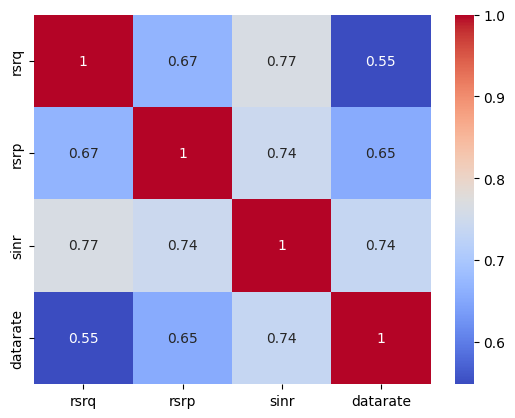

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[['rsrq', 'rsrp', 'sinr', 'datarate']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# features = ['rsrp', 'sinr', 'datarate']
features = ['rsrp', 'sinr', 'datarate', 'dlat', 'dlong']
target = 'rsrq'


df_clean = df[features + [target]].dropna()

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model = RandomForestRegressor(n_estimators=100, random_state=42)
model = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} dB")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

MAE: 0.77 dB
R2 Score: 0.80


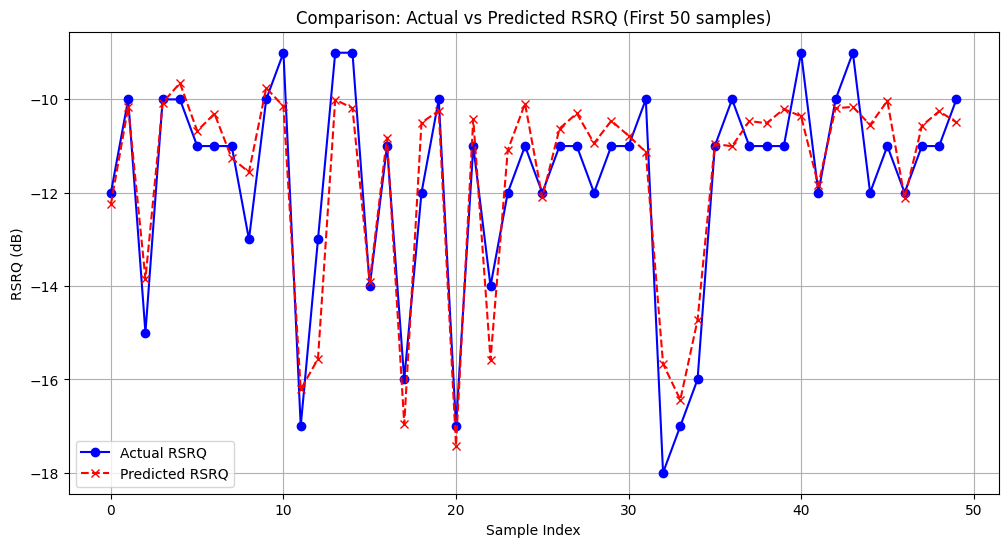

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual RSRQ', marker='o', color='blue')
plt.plot(y_pred[:50], label='Predicted RSRQ', linestyle='--', marker='x', color='red')
plt.title('Comparison: Actual vs Predicted RSRQ (First 50 samples)')
plt.xlabel('Sample Index')
plt.ylabel('RSRQ (dB)')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
importances = model.feature_importances_
for feature, importance in zip(features, importances):
    print(f"Feature: {feature}, Importance: {importance:.4f}")

Feature: rsrp, Importance: 0.0493
Feature: sinr, Importance: 0.8044
Feature: datarate, Importance: 0.0601
Feature: dlat, Importance: 0.0392
Feature: dlong, Importance: 0.0469


In [8]:
import joblib

model_filename = 'rsrq_estimator_model.pkl'

joblib.dump(model, model_filename)

print(f"model saved successfully as: {model_filename}.")

model saved successfully as: rsrq_estimator_model.pkl.


In [9]:
import joblib
import pandas as pd

loaded_model = joblib.load('rsrq_estimator_model.pkl')
print("model loaded successfully.")

# df_tehran = pd.read_csv('tehran_drive_test.csv')

# new_data = df_tehran[['rsrp', 'sinr', 'datarate', 'dlat', 'dlong']]

predictions = loaded_model.predict(X_test)
# predictions = loaded_model.predict(new_data)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} dB")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")


model loaded successfully.
MAE: 0.77 dB
R2 Score: 0.80


In [11]:
# Data manipulation
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Geospatial
import folium
from folium.plugins import HeatMap

# Model persistence
import joblib

# Utilities
import time
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")


✓ All libraries imported successfully!
XGBoost version: 3.1.2


### Load Data

In [12]:
# Load dataset
df = pd.read_csv('SRFG-v1.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {len(df):,}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
df.info()


Dataset Shape: (267198, 22)
Total Records: 267,198

First 5 rows:
                  time        lat       long    ele  newpos  rsrq   cell_id  \
0  2018-01-15 16:43:52  47.847847  13.080113  505.1    True  -6.0  798470.0   
1  2018-01-15 16:43:53  47.848070  13.080318  505.2    True  -7.0  798470.0   
2  2018-01-15 16:43:54  47.848280  13.080542  505.5    True  -7.0  798470.0   
3  2018-01-15 16:43:55  47.848484  13.080778  505.7    True  -6.0  798470.0   
4  2018-01-15 16:43:56  47.848680  13.081034  505.8    True  -7.0  798470.0   

   sinr  signal    pci  ...  technology  rsrp   datarate             file  \
0  28.0     5.0  468.0  ...         LTE -65.0  5554624.0  2018-01-15-1736   
1  24.0     5.0  468.0  ...         LTE -68.0  4814816.0  2018-01-15-1736   
2  22.0     5.0  468.0  ...         LTE -67.0  5081632.0  2018-01-15-1736   
3  22.0     5.0  468.0  ...         LTE -70.0  5506112.0  2018-01-15-1736   
4  17.0     5.0  468.0  ...         LTE -77.0  5518240.0  2018-01-15-1736 

### Data Preparation

In [13]:
# Define features and target
features = ['rsrp', 'sinr', 'datarate', 'dlat', 'dlong']
target = 'rsrq'

# Clean dataset - remove missing values
df_clean = df[features + [target, 'lat', 'long']].dropna()

print(f"Clean dataset size: {len(df_clean):,} samples")
print(f"Removed {len(df) - len(df_clean):,} rows with missing values")

# Prepare features and target
X = df_clean[features]
y = df_clean[target]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Save coordinates for heatmap
coords_test = df_clean.loc[y_test.index, ['lat', 'long']].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

print(f"\nTraining samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")
print(f"\nFeatures: {features}")


Clean dataset size: 255,479 samples
Removed 11,719 rows with missing values

Training samples: 204,383
Testing samples: 51,096

Features: ['rsrp', 'sinr', 'datarate', 'dlat', 'dlong']


### Correlation Analysis

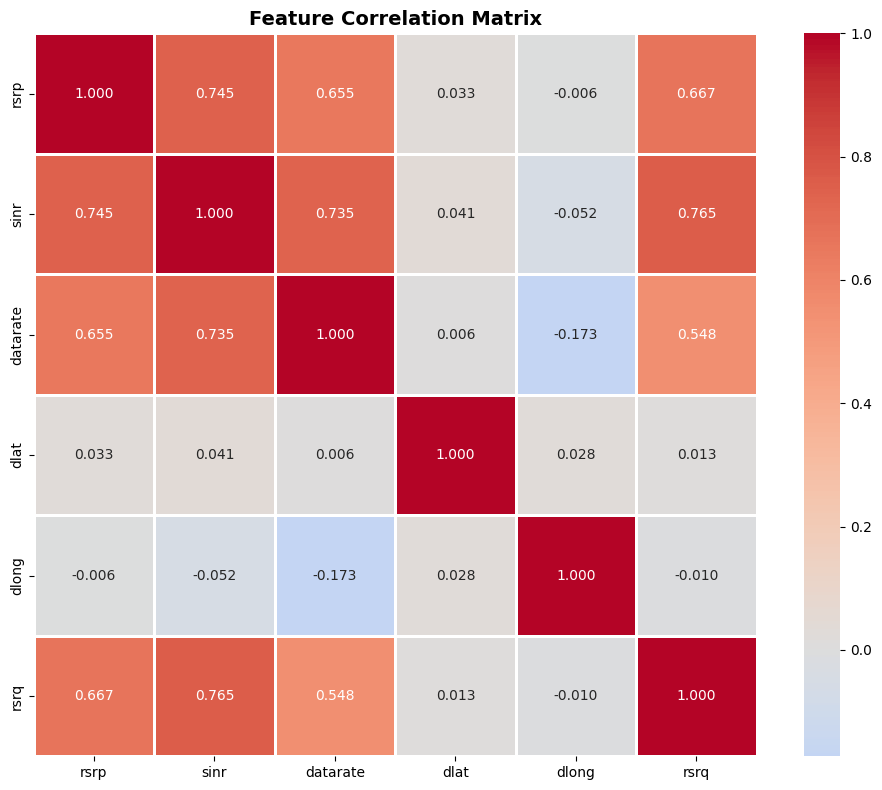


Correlation with RSRQ (Target):
rsrq        1.000000
sinr        0.765178
rsrp        0.666773
datarate    0.547928
dlat        0.013301
dlong      -0.009682
Name: rsrq, dtype: float64


In [14]:
# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_data = df_clean[features + [target]]
corr_matrix = correlation_data.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with RSRQ (Target):")
print(corr_matrix[target].sort_values(ascending=False))


### Train Random Forest Model

In [ ]:
print("="*70)
print("TRAINING RANDOM FOREST MODEL")
print("="*70)

# Random Forest configuration
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,  # Use all CPU cores
    random_state=42,
    verbose=1
)

# Train
print("\nTraining Random Forest...")
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_training_time = time.time() - start_time

# Predict
y_pred_rf = rf_model.predict(X_test)

# Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n{'='*70}")
print("RANDOM FOREST RESULTS:")
print(f"{'='*70}")
print(f"Training Time: {rf_training_time:.2f} seconds")
print(f"MAE (Mean Absolute Error): {mae_rf:.4f} dB")
print(f"RMSE (Root Mean Squared Error): {rmse_rf:.4f} dB")
print(f"R² Score: {r2_rf:.4f} ")
print(f"{'='*70}")


TRAINING RANDOM FOREST MODEL

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:   10.0s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   18.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.6s



RANDOM FOREST RESULTS:
Training Time: 18.08 seconds
MAE (Mean Absolute Error): 0.7648 dB
RMSE (Root Mean Squared Error): 1.0025 dB
R² Score: 0.8018 (80.18% variance explained)


[Parallel(n_jobs=20)]: Done 300 out of 300 | elapsed:    1.1s finished


### Random Forest Feature Importance

Random Forest Feature Importance:
 Feature  Importance
    sinr    0.479024
    rsrp    0.253207
datarate    0.188775
   dlong    0.040316
    dlat    0.038678


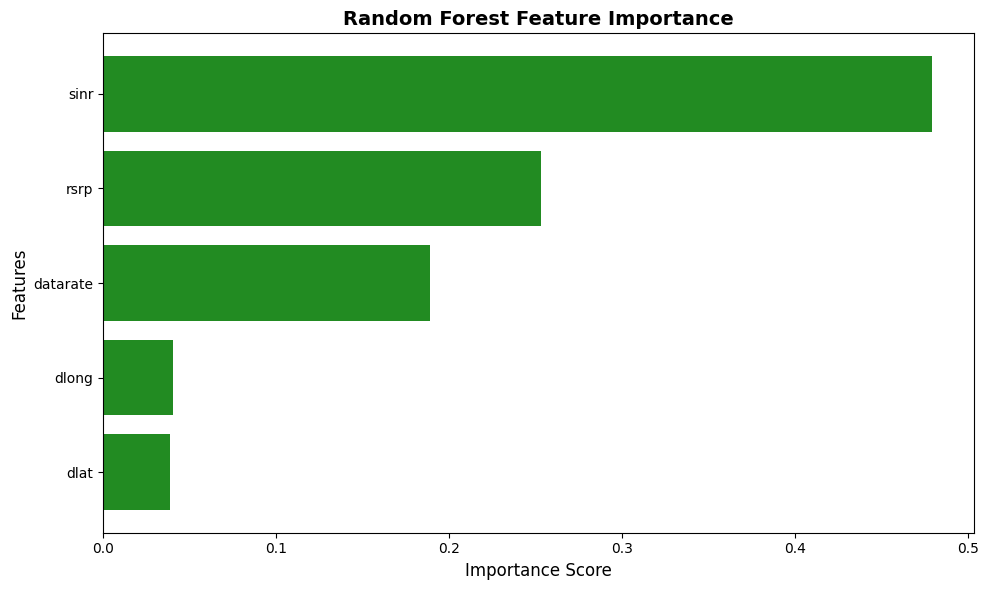

In [16]:
# Feature importance
rf_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importance:")
print(rf_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(rf_importance['Feature'], rf_importance['Importance'], color='forestgreen')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Train XGBoost Model 

In [ ]:
print("="*70)
print("TRAINING XGBOOST MODEL")
print("="*70)

print(f"XGBoost version: {xgb.__version__}")

# Simple XGBoost model without GPU complications
# XGBoost will automatically use the best available device
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,  # Use all CPU cores
    tree_method='hist' , # Fast histogram-based algorithm
    device="cuda"

)

print("✓ XGBoost model initialized")

# Train
print("\nTraining XGBoost...")
start_time = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
xgb_training_time = time.time() - start_time

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\n{'='*70}")
print("XGBOOST RESULTS:")
print(f"{'='*70}")
print(f"Training Time: {xgb_training_time:.2f} seconds")
print(f"MAE (Mean Absolute Error): {mae_xgb:.4f} dB")
print(f"RMSE (Root Mean Squared Error): {rmse_xgb:.4f} dB")
print(f"R² Score: {r2_xgb:.4f} ({r2_xgb*100:.2f}% variance explained)")
print(f"{'='*70}")


TRAINING XGBOOST MODEL
XGBoost version: 3.1.2
✓ XGBoost model initialized (using CPU)

Training XGBoost...
[0]	validation_0-rmse:2.08118
[50]	validation_0-rmse:1.01290
[100]	validation_0-rmse:1.00292
[150]	validation_0-rmse:0.99954
[200]	validation_0-rmse:0.99841
[250]	validation_0-rmse:0.99775
[300]	validation_0-rmse:0.99848
[350]	validation_0-rmse:0.99865
[400]	validation_0-rmse:1.00004
[450]	validation_0-rmse:1.00112
[499]	validation_0-rmse:1.00250

XGBOOST RESULTS:
Training Time: 5.14 seconds
MAE (Mean Absolute Error): 0.7614 dB
RMSE (Root Mean Squared Error): 1.0025 dB
R² Score: 0.8018 (80.18% variance explained)


### XGBoost Feature Importance

XGBoost Feature Importance:
 Feature  Importance
    sinr    0.758310
    rsrp    0.115252
datarate    0.055551
    dlat    0.039187
   dlong    0.031701


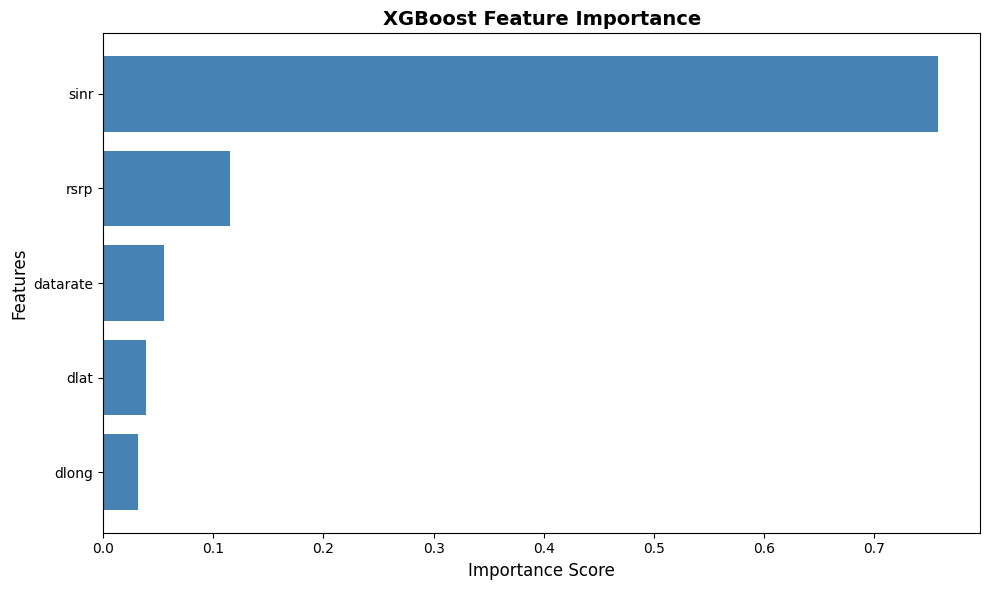

In [25]:
# Feature importance
xgb_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("XGBoost Feature Importance:")
print(xgb_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(xgb_importance['Feature'], xgb_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Model Comparison


MODEL COMPARISON
        Model  Training Time (s)  MAE (dB)  RMSE (dB)  R² Score
Random Forest          18.078688  0.764807   1.002518  0.801820
      XGBoost           5.139215  0.761444   1.002501  0.801827

🏆 Best Model: XGBoost


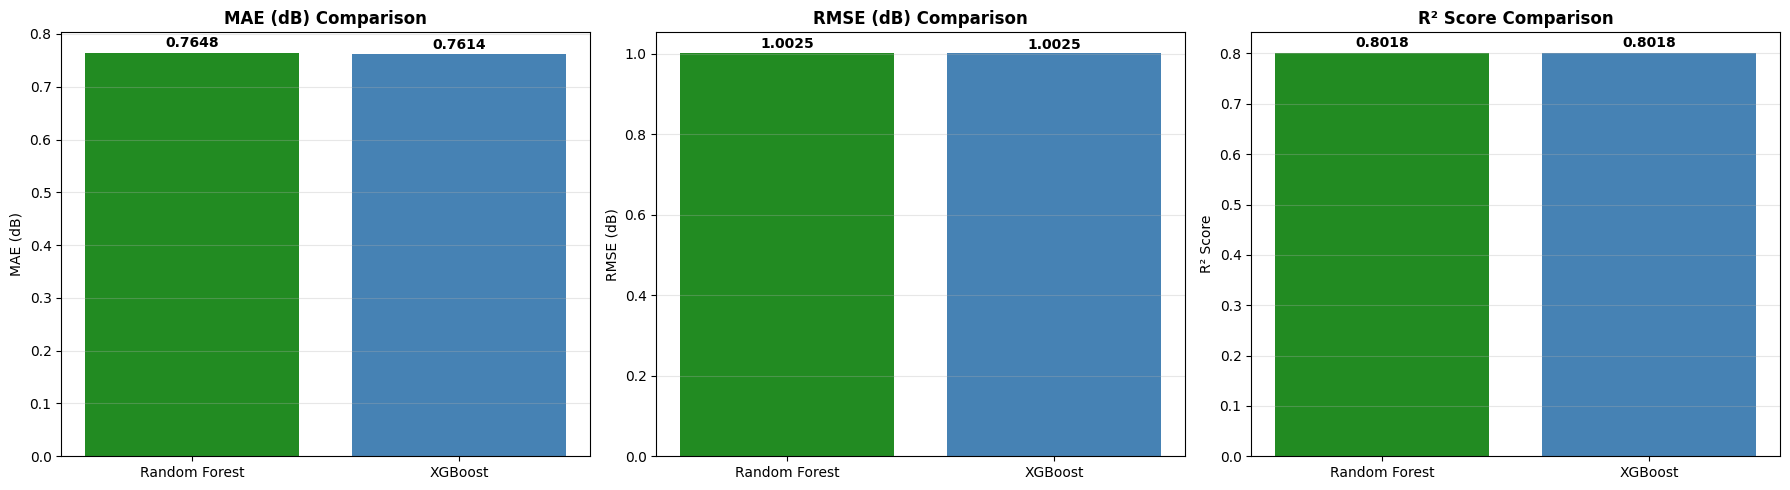

In [26]:
# Compare models
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Training Time (s)': [rf_training_time, xgb_training_time],
    'MAE (dB)': [mae_rf, mae_xgb],
    'RMSE (dB)': [rmse_rf, rmse_xgb],
    'R² Score': [r2_rf, r2_xgb]
})

print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Determine best model
best_model_name = 'Random Forest' if mae_rf < mae_xgb else 'XGBoost'
best_model = rf_model if mae_rf < mae_xgb else xgb_model
y_pred_best = y_pred_rf if mae_rf < mae_xgb else y_pred_xgb

print(f"\n🏆 Best Model: {best_model_name}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['MAE (dB)', 'RMSE (dB)', 'R² Score']
colors = ['forestgreen', 'steelblue']

for idx, metric in enumerate(metrics):
    axes[idx].bar(comparison_df['Model'], comparison_df[metric], color=colors)
    axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(comparison_df[metric]):
        axes[idx].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### Prediction Visualization (Static)

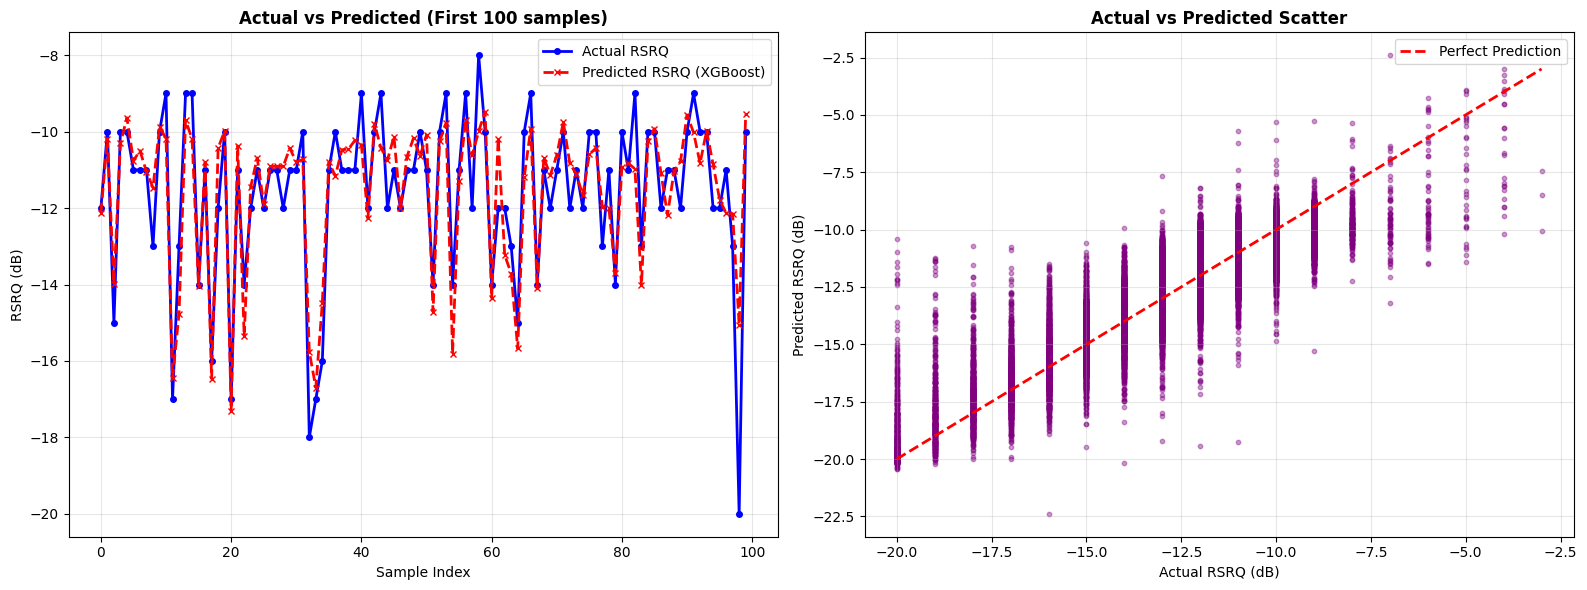

In [27]:
# Actual vs Predicted comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line plot (first 100 samples)
sample_size = 100
axes[0].plot(y_test.values[:sample_size], label='Actual RSRQ', 
             marker='o', linewidth=2, markersize=4, color='blue')
axes[0].plot(y_pred_best[:sample_size], label=f'Predicted RSRQ ({best_model_name})', 
             linestyle='--', marker='x', linewidth=2, markersize=4, color='red')
axes[0].set_title(f'Actual vs Predicted (First {sample_size} samples)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('RSRQ (dB)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter plot
axes[1].scatter(y_test, y_pred_best, alpha=0.4, s=10, color='purple')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted Scatter', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual RSRQ (dB)')
axes[1].set_ylabel('Predicted RSRQ (dB)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Error Analysis

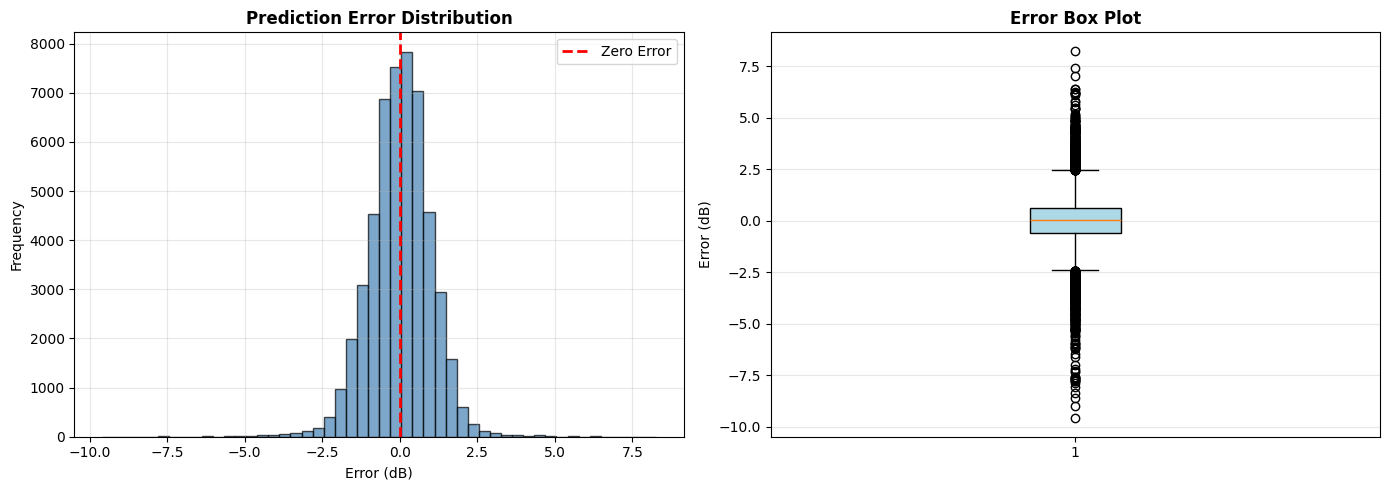

ERROR ANALYSIS
Mean Error: 0.0014 dB
Std Deviation: 1.0025 dB
Min Error: -9.5941 dB
Max Error: 8.2643 dB
Median Error: 0.0336 dB
25th Percentile: -0.5896 dB
75th Percentile: 0.6256 dB


In [28]:
# Calculate errors
errors = y_test.values - y_pred_best

# Error visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_title('Prediction Error Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Error (dB)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
bp = axes[1].boxplot(errors, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[1].set_title('Error Box Plot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Error (dB)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Error statistics
print("="*70)
print("ERROR ANALYSIS")
print("="*70)
print(f"Mean Error: {np.mean(errors):.4f} dB")
print(f"Std Deviation: {np.std(errors):.4f} dB")
print(f"Min Error: {np.min(errors):.4f} dB")
print(f"Max Error: {np.max(errors):.4f} dB")
print(f"Median Error: {np.median(errors):.4f} dB")
print(f"25th Percentile: {np.percentile(errors, 25):.4f} dB")
print(f"75th Percentile: {np.percentile(errors, 75):.4f} dB")
print("="*70)


### Interactive Visualization (Plotly)

In [33]:
print("Creating interactive visualization with Plotly...")

# Create interactive scatter plot
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=y_test.values,
    y=y_pred_best,
    mode='markers',
    name='Predictions',
    marker=dict(
        size=5,
        color=y_test.values,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Actual RSRQ (dB)")
    ),
    text=[f'Actual: {a:.2f} dB<br>Predicted: {p:.2f} dB<br>Error: {a-p:.2f} dB' 
          for a, p in zip(y_test.values, y_pred_best)],
    hovertemplate='%{text}<extra></extra>'
))

# Add perfect prediction line
fig.add_trace(go.Scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    name='Perfect Prediction',
    line=dict(color='red', width=3, dash='dash')
))

# Update layout
fig.update_layout(
    title=f'{best_model_name}: Interactive Actual vs Predicted RSRQ',
    xaxis_title='Actual RSRQ (dB)',
    yaxis_title='Predicted RSRQ (dB)',
    hovermode='closest',
    width=900,
    height=600,
    template='plotly_white'
)

import plotly.io as pio
pio.renderers.default = "browser"

fig.show()

# Save interactive plot
fig.write_html('interactive_predictions.html')
print("✓ Interactive plot saved to 'interactive_predictions.html'")


Creating interactive visualization with Plotly...
Opening in existing browser session.
✓ Interactive plot saved to 'interactive_predictions.html'


### Geographic Heatmap - Actual RSRQ

In [35]:
print("Creating geographic heatmap for Actual RSRQ...")

# Prepare data
heatmap_actual = pd.DataFrame({
    'lat': coords_test['lat'],
    'long': coords_test['long'],
    'rsrq': y_test_reset
})

# Remove any NaN values
heatmap_actual = heatmap_actual.dropna()

# Normalize RSRQ for color intensity (0-1 scale)
rsrq_min = heatmap_actual['rsrq'].min()
rsrq_max = heatmap_actual['rsrq'].max()
heatmap_actual['rsrq_norm'] = (heatmap_actual['rsrq'] - rsrq_min) / (rsrq_max - rsrq_min)

# Create base map centered on data
center_lat = heatmap_actual['lat'].mean()
center_long = heatmap_actual['long'].mean()

map_actual = folium.Map(
    location=[center_lat, center_long],
    zoom_start=12,
    tiles='OpenStreetMap'
)

# Prepare heatmap data: [[lat, long, intensity], ...]
heat_data_actual = heatmap_actual[['lat', 'long', 'rsrq_norm']].values.tolist()

# Add heatmap layer
HeatMap(
    heat_data_actual,
    min_opacity=0.4,
    max_zoom=18,
    radius=15,
    blur=20,
    gradient={
        0.0: 'red',      # Poor signal
        0.25: 'orange',
        0.5: 'yellow',   # Medium signal
        0.75: 'lightgreen',
        1.0: 'green'     # Excellent signal
    }
).add_to(map_actual)

# Add legend
legend_html = '''
<div style="position: fixed; top: 10px; right: 10px; width: 220px; height: 140px; 
     background-color: white; border:2px solid grey; z-index:9999; font-size:14px; padding: 10px">
     <b>Actual RSRQ Signal Quality</b><br><br>
     <i style="background: green; width: 20px; height: 10px; display: inline-block;"></i> Excellent (-3 to -10 dB)<br>
     <i style="background: lightgreen; width: 20px; height: 10px; display: inline-block;"></i> Good (-10 to -15 dB)<br>
     <i style="background: yellow; width: 20px; height: 10px; display: inline-block;"></i> Fair (-15 to -20 dB)<br>
     <i style="background: orange; width: 20px; height: 10px; display: inline-block;"></i> Poor (-20 to -25 dB)<br>
     <i style="background: red; width: 20px; height: 10px; display: inline-block;"></i> Very Poor (< -25 dB)<br>
</div>
'''
map_actual.get_root().html.add_child(folium.Element(legend_html))

# Save map
map_actual.save('heatmap_actual_rsrq.html')
print(f"✓ Actual RSRQ heatmap saved to 'heatmap_actual_rsrq.html'")
print(f"  Data points: {len(heatmap_actual):,}")
print(f"  RSRQ range: {rsrq_min:.2f} to {rsrq_max:.2f} dB")


Creating geographic heatmap for Actual RSRQ...
✓ Actual RSRQ heatmap saved to 'heatmap_actual_rsrq.html'
  Data points: 51,096
  RSRQ range: -20.00 to -3.00 dB


### Save Models

In [37]:
print("="*70)
print("SAVING MODELS")
print("="*70)

# Save Random Forest
joblib.dump(rf_model, 'random_forest_model.pkl')
print("✓ Random Forest model saved to 'random_forest_model.pkl'")

# Save XGBoost
xgb_model.get_booster().save_model('xgboost_model.json')
print("✓ XGBoost model saved to 'xgboost_model.json'")

# Save feature list
import json
with open('features.json', 'w') as f:
    json.dump(features, f)
print("✓ Feature list saved to 'features.json'")

# Save model performance metrics
metrics = {
    'Random Forest': {
        'MAE': float(mae_rf),
        'RMSE': float(rmse_rf),
        'R2': float(r2_rf),
        'Training Time': float(rf_training_time)
    },
    'XGBoost': {
        'MAE': float(mae_xgb),
        'RMSE': float(rmse_xgb),
        'R2': float(r2_xgb),
        'Training Time': float(xgb_training_time)
    },
    'Best Model': best_model_name
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("✓ Model metrics saved to 'model_metrics.json'")

print("="*70)
print("All models saved successfully!")
print("="*70)


SAVING MODELS
✓ Random Forest model saved to 'random_forest_model.pkl'
✓ XGBoost model saved to 'xgboost_model.json'
✓ Feature list saved to 'features.json'
✓ Model metrics saved to 'model_metrics.json'
All models saved successfully!


### Load and Test Models

In [38]:
print("="*70)
print("LOADING AND TESTING SAVED MODELS")
print("="*70)

# Load Random Forest
rf_loaded = joblib.load('random_forest_model.pkl')
print("✓ Random Forest model loaded")

# Load XGBoost
xgb_loaded = xgb.XGBRegressor()
xgb_loaded.load_model('xgboost_model.json')
print("✓ XGBoost model loaded")

# Load features
with open('features.json', 'r') as f:
    features_loaded = json.load(f)
print(f"✓ Features loaded: {features_loaded}")

# Load metrics
with open('model_metrics.json', 'r') as f:
    metrics_loaded = json.load(f)
print("✓ Model metrics loaded")

# Test with sample data
print("\n" + "="*70)
print("TESTING WITH SAMPLE DATA")
print("="*70)

sample = X_test.iloc[0:5]
actual = y_test.iloc[0:5]

print("\nSample Input Data:")
print(sample)

# Predictions
pred_rf_test = rf_loaded.predict(sample)
pred_xgb_test = xgb_loaded.predict(sample)

# Display results
results_test = pd.DataFrame({
    'Actual RSRQ': actual.values,
    'RF Prediction': pred_rf_test,
    'RF Error': actual.values - pred_rf_test,
    'XGB Prediction': pred_xgb_test,
    'XGB Error': actual.values - pred_xgb_test
})

print("\nPrediction Results:")
print(results_test.to_string(index=False))
print("="*70)


LOADING AND TESTING SAVED MODELS
✓ Random Forest model loaded
✓ XGBoost model loaded
✓ Features loaded: ['rsrp', 'sinr', 'datarate', 'dlat', 'dlong']
✓ Model metrics loaded

TESTING WITH SAMPLE DATA

Sample Input Data:
         rsrp  sinr     datarate      dlat     dlong
89422   -99.0   5.0   11570112.0 -0.000015 -0.000043
110037  -73.0  24.0  106694960.0 -0.000072 -0.000297
116496 -105.0  -5.0   14786408.0 -0.000050 -0.000491
96764   -63.0  21.0   63543230.0  0.000095  0.000355
119147  -78.0  16.0   44435070.0  0.000160 -0.000387


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 300 out of 300 | elapsed:    0.2s finished



Prediction Results:
 Actual RSRQ  RF Prediction  RF Error  XGB Prediction  XGB Error
       -12.0     -11.994356 -0.005644      -12.125724   0.125724
       -10.0     -10.137130  0.137130      -10.182257   0.182257
       -15.0     -13.880701 -1.119299      -13.983575  -1.016425
       -10.0     -10.082623  0.082623      -10.299845   0.299845
       -10.0      -9.642037 -0.357963       -9.637952  -0.362048


### summary report

In [40]:
print("="*70)
print("FINAL SUMMARY REPORT")
print("="*70)

print(f"\nDataset Information:")
print(f"   Total samples: {len(df_clean):,}")
print(f"   Training samples: {len(X_train):,}")
print(f"   Testing samples: {len(X_test):,}")
print(f"   Features used: {len(features)}")

print(f"\nModel Performance:")
print(f"\n   Random Forest:")
print(f"   • MAE: {mae_rf:.4f} dB")
print(f"   • RMSE: {rmse_rf:.4f} dB")
print(f"   • R² Score: {r2_rf:.4f} ({r2_rf*100:.2f}%)")
print(f"   • Training Time: {rf_training_time:.2f} seconds")

print(f"\n   XGBoost:")
print(f"   • MAE: {mae_xgb:.4f} dB")
print(f"   • RMSE: {rmse_xgb:.4f} dB")
print(f"   • R² Score: {r2_xgb:.4f} ({r2_xgb*100:.2f}%)")
print(f"   • Training Time: {xgb_training_time:.2f} seconds")

print(f"\n Best Model: {best_model_name}")


print("\n" + "="*70)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)


FINAL SUMMARY REPORT

Dataset Information:
   Total samples: 255,479
   Training samples: 204,383
   Testing samples: 51,096
   Features used: 5

Model Performance:

   Random Forest:
   • MAE: 0.7648 dB
   • RMSE: 1.0025 dB
   • R² Score: 0.8018 (80.18%)
   • Training Time: 18.08 seconds

   XGBoost:
   • MAE: 0.7614 dB
   • RMSE: 1.0025 dB
   • R² Score: 0.8018 (80.18%)
   • Training Time: 5.14 seconds

 Best Model: XGBoost

PROJECT COMPLETED SUCCESSFULLY!
